# Model Analysis and Testing

This notebook tests the trained ST-SSL model on the test dataset and visualizes the results.

In [41]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import argparse
import yaml

# Add root directory to path
sys.path.append(os.path.abspath('.'))

from model.models import STSSL
from lib.dataloader import get_dataloader
from lib.utils import load_graph, get_model_params

%matplotlib inline

## Configuration

Load configuration from the experiment logs.

In [42]:
# Recreating args from run.log
# Using CPU mode to avoid persistent GPU memory issues
args = argparse.Namespace(
    batch_size=32, 
    best_path='experiments/PEMS08_Occupancy/20260127-142848/best_model.pth', 
    d_input=2, 
    d_model=64, 
    d_output=2, 
    data_dir='data', 
    dataset='PEMS08_Occupancy', 
    debug=False, 
    device='cpu',  # Using CPU to avoid GPU OOM issues
    dropout=0.2, 
    early_stop=True, 
    early_stop_patience=15, 
    epochs=100, 
    grad_norm=True, 
    graph_file='data/PEMS08_Occupancy/adj_mx.npz', 
    input_length=12, 
    log_dir='experiments/PEMS08_Occupancy/20260127-142848', 
    lr_init=0.001, 
    max_grad_norm=5, 
    mode='test', 
    nmb_prototype=6, 
    num_nodes=170, 
    percent=0.1, 
    seed=31, 
    shm_temp=0.5, 
    temp=4, 
    test_batch_size=8, 
    use_dwa=True, 
    yita=0.6
)

print(f"Using device: {args.device}")

Using device: cpu


In [43]:
# Using CPU mode - skip CUDA operations
print(f"Running on: {args.device}")

Running on: cpu


## Load Data

Load the test dataset and the graph structure.

In [44]:
# Workaround: Temporarily disable CUDA to prevent OOM when loading data
# The dataloader tries to load all data onto GPU, which causes OOM errors
import gc
gc.collect()

_cuda_available = torch.cuda.is_available
torch.cuda.is_available = lambda: False

dataloader = get_dataloader(
    data_dir=args.data_dir, 
    dataset=args.dataset, 
    batch_size=args.batch_size, 
    test_batch_size=args.test_batch_size,
)

# Restore CUDA availability
torch.cuda.is_available = _cuda_available

# Load graph
graph_data = np.load(args.graph_file)['adj_mx']
graph = torch.tensor(graph_data, dtype=torch.float).to(args.device)
args.num_nodes = len(graph)

print(f"Loaded dataset with {len(dataloader['test'])} batches for testing.")
print(f"Graph size: {args.num_nodes} nodes.")

Loaded dataset with 447 batches for testing.
Graph size: 170 nodes.


## Load Model

Initialize the model and load the best weights.

In [45]:
model = STSSL(args).to(args.device)

if os.path.exists(args.best_path):
    state_dict = torch.load(args.best_path, map_location=torch.device(args.device))
    if 'model' in state_dict:
        model.load_state_dict(state_dict['model'])
    else:
        model.load_state_dict(state_dict)
    print("Model weights loaded successfully.")
else:
    print(f"Error: Model file not found at {args.best_path}")

Model weights loaded successfully.


## Run Inference

Run the model on the test set and collect predictions.

In [46]:
model.eval()
y_pred = []
y_true = []
scaler = dataloader['scaler']

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(dataloader['test']):
        data = data.to(args.device)
        target = target.to(args.device)
        
        repr1, repr2 = model(data, graph)
        pred_output = model.predict(repr1, repr2)

        y_true.append(target)
        y_pred.append(pred_output)

y_true = scaler.inverse_transform(torch.cat(y_true, dim=0))
y_pred = scaler.inverse_transform(torch.cat(y_pred, dim=0))

print("Inference complete.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

Inference complete.
y_true shape: torch.Size([3570, 1, 170, 2])
y_pred shape: torch.Size([3570, 1, 170, 2])


## Evaluation Metrics

Calculate RMSE, MAE, MAPE, and R² scores.

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_mape(y_true, y_pred, epsilon=1e-8):
    """Calculate Mean Absolute Percentage Error, handling zero values."""
    y_true_np = y_true.cpu().numpy().flatten()
    y_pred_np = y_pred.cpu().numpy().flatten()
    # Avoid division by zero
    mask = np.abs(y_true_np) > epsilon
    return np.mean(np.abs((y_true_np[mask] - y_pred_np[mask]) / y_true_np[mask])) * 100

# Flatten tensors for metric calculation
y_true_flat = y_true.cpu().numpy().flatten()
y_pred_flat = y_pred.cpu().numpy().flatten()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae = mean_absolute_error(y_true_flat, y_pred_flat)
mape = calculate_mape(y_true, y_pred)
r2 = r2_score(y_true_flat, y_pred_flat)

print("=" * 50)
print("EVALUATION METRICS")
print("=" * 50)
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE  (Mean Absolute Error):     {mae:.4f}")
print(f"MAPE (Mean Absolute % Error):   {mape:.2f}%")
print(f"R²   (Coefficient of Determination): {r2:.4f}")
print("=" * 50)

# Per-feature metrics (if multiple features exist)
if y_true.shape[-1] > 1:
    print("\nPer-Feature Metrics:")
    feature_names = ['Feature 0 (Inflow)', 'Feature 1 (Outflow)'] if y_true.shape[-1] == 2 else [f'Feature {i}' for i in range(y_true.shape[-1])]
    for i, name in enumerate(feature_names):
        y_t = y_true[..., i].cpu().numpy().flatten()
        y_p = y_pred[..., i].cpu().numpy().flatten()
        print(f"\n  {name}:")
        print(f"    RMSE: {np.sqrt(mean_squared_error(y_t, y_p)):.4f}")
        print(f"    MAE:  {mean_absolute_error(y_t, y_p):.4f}")
        print(f"    R²:   {r2_score(y_t, y_p):.4f}")

EVALUATION METRICS
RMSE (Root Mean Squared Error): 1.4960
MAE  (Mean Absolute Error):     0.7693
MAPE (Mean Absolute % Error):   1.50%
R²   (Coefficient of Determination): 0.9538

Per-Feature Metrics:

  Feature 0 (Inflow):
    RMSE: 1.4970
    MAE:  0.7693
    R²:   0.9538

  Feature 1 (Outflow):
    RMSE: 1.4950
    MAE:  0.7693
    R²:   0.9539


## Visualization

### Time Series Prediction vs Ground Truth

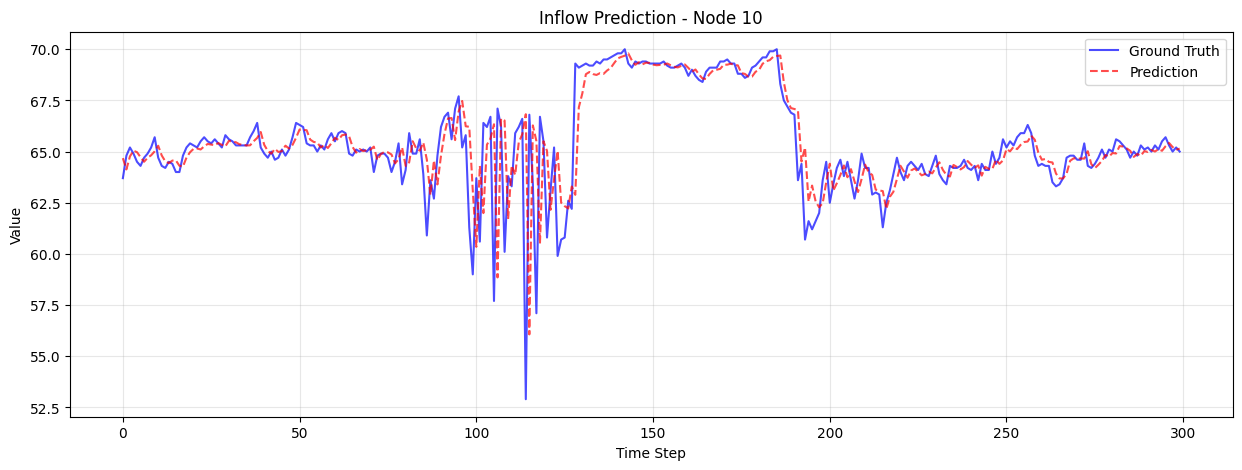

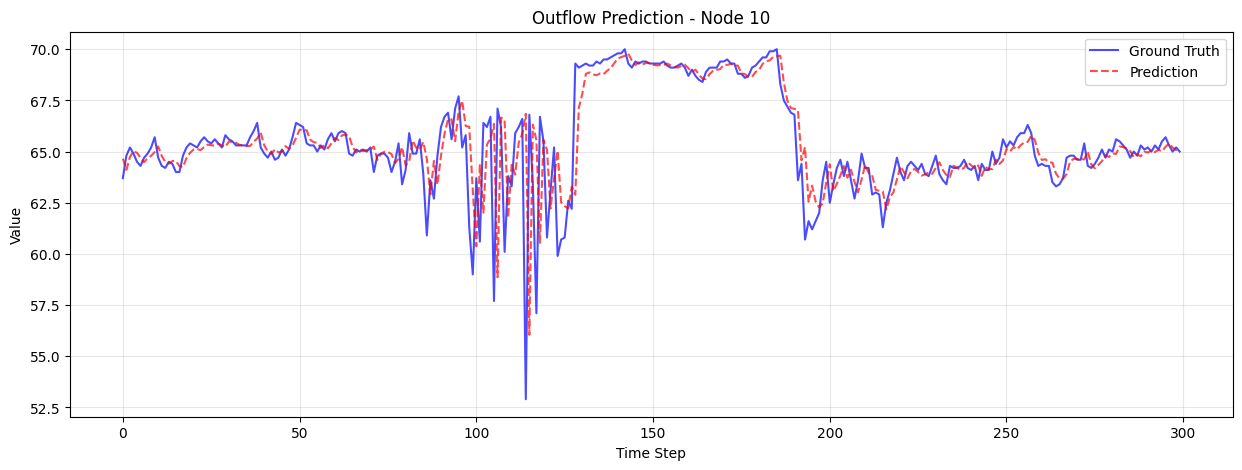

In [47]:
def plot_prediction(y_true, y_pred, node_idx=0, time_steps=200, feature_idx=0, title="Traffic Flow"):
    plt.figure(figsize=(15, 5))
    
    # Convert to numpy and flatten (selecting first time step of prediction window if multiple exist)
    # y_true shape: (Batch, 1, Node, Feature)
    # We visualize the first step of the output window for a continuous series
    gt = y_true[:time_steps, 0, node_idx, feature_idx].cpu().numpy()
    pred = y_pred[:time_steps, 0, node_idx, feature_idx].cpu().numpy()
    
    plt.plot(gt, label='Ground Truth', color='blue', alpha=0.7)
    plt.plot(pred, label='Prediction', color='red', alpha=0.7, linestyle='--')
    
    plt.title(f'{title} Prediction - Node {node_idx}')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot for Inflow (Feature 0)
plot_prediction(y_true, y_pred, node_idx=10, time_steps=300, feature_idx=0, title="Inflow")

# Plot for Outflow (Feature 1)
plot_prediction(y_true, y_pred, node_idx=10, time_steps=300, feature_idx=1, title="Outflow")

### Per-Node Metrics Heatmaps

Visualize MAE, RMSE, and MAPE for all 170 nodes in a 17x10 grid layout.

In [51]:
# Calculate per-node metrics
num_nodes = args.num_nodes
node_mae = np.zeros(num_nodes)
node_rmse = np.zeros(num_nodes)
node_mape = np.zeros(num_nodes)

# y_true and y_pred shape: (Batch, 1, Nodes, Features)
y_true_np = y_true.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()

for node in range(num_nodes):
    # Get all predictions for this node (all time steps, all features)
    y_t = y_true_np[:, :, node, :].flatten()
    y_p = y_pred_np[:, :, node, :].flatten()
    
    node_mae[node] = np.mean(np.abs(y_t - y_p))
    node_rmse[node] = np.sqrt(np.mean((y_t - y_p) ** 2))
    
    # MAPE with zero handling
    mask = np.abs(y_t) > 1e-8
    if np.sum(mask) > 0:
        node_mape[node] = np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100
    else:
        node_mape[node] = 0

print(f"Per-node metrics calculated for {num_nodes} nodes")
print(f"MAE  - Min: {node_mae.min():.4f}, Max: {node_mae.max():.4f}, Mean: {node_mae.mean():.4f}")
print(f"RMSE - Min: {node_rmse.min():.4f}, Max: {node_rmse.max():.4f}, Mean: {node_rmse.mean():.4f}")
print(f"MAPE - Min: {node_mape.min():.2f}%, Max: {node_mape.max():.2f}%, Mean: {node_mape.mean():.2f}%")

Per-node metrics calculated for 170 nodes
MAE  - Min: 0.1135, Max: 2.8505, Mean: 0.7693
RMSE - Min: 0.2557, Max: 4.2909, Mean: 1.2445
MAPE - Min: 0.18%, Max: 16.77%, Mean: 1.50%


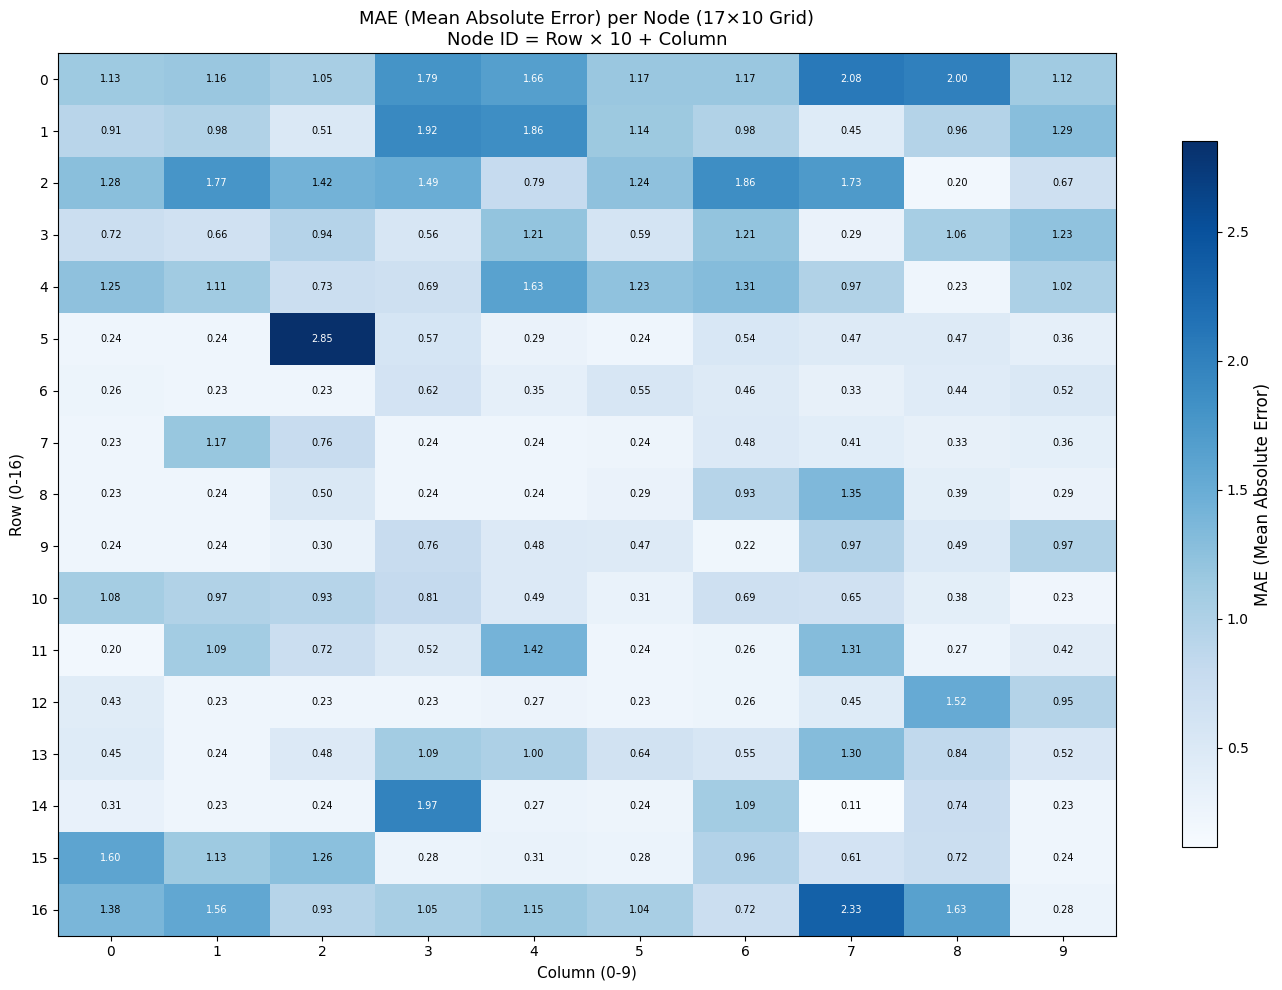

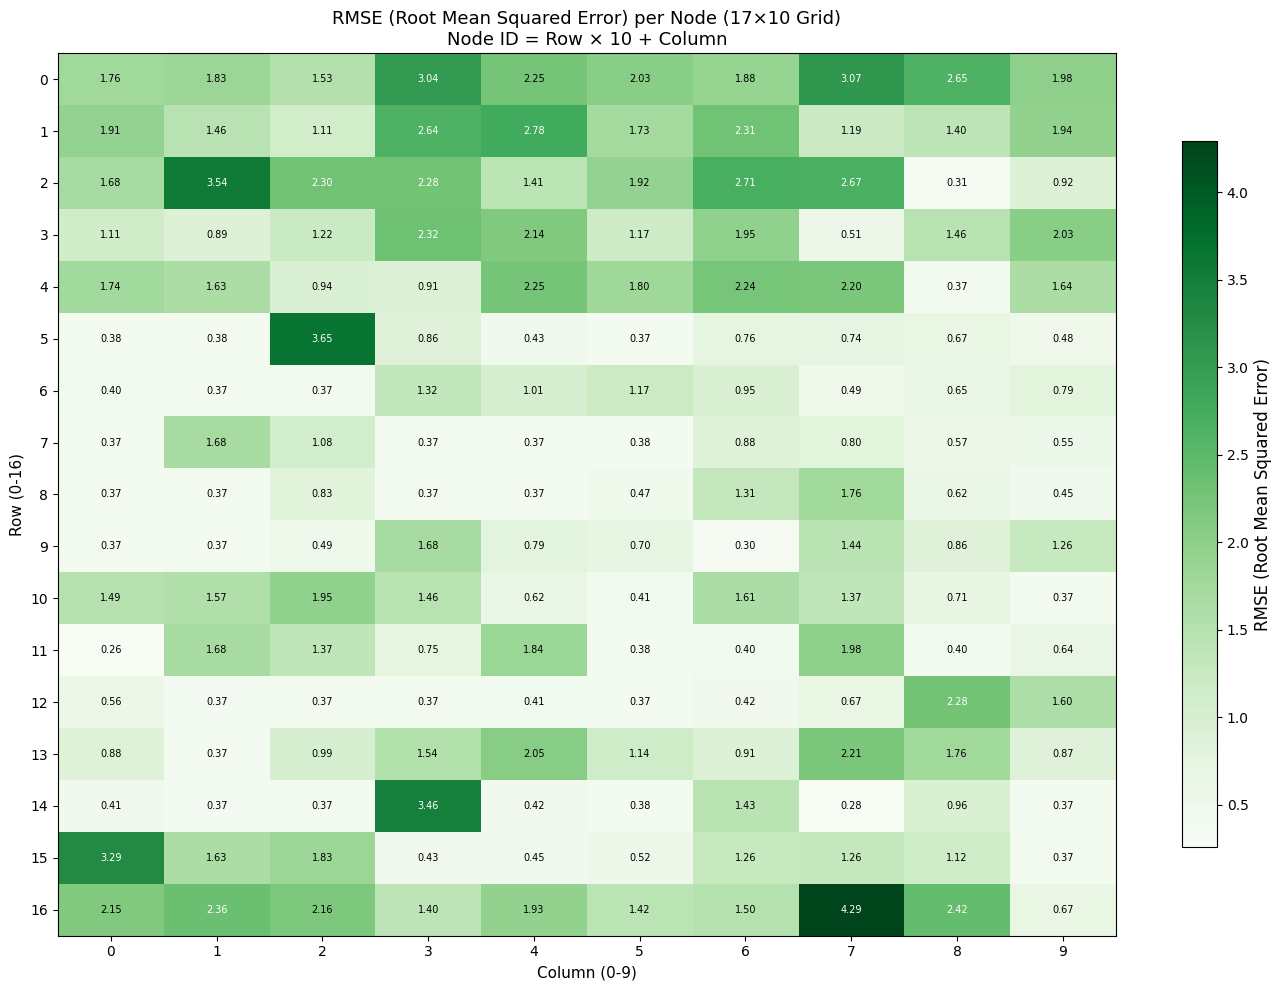

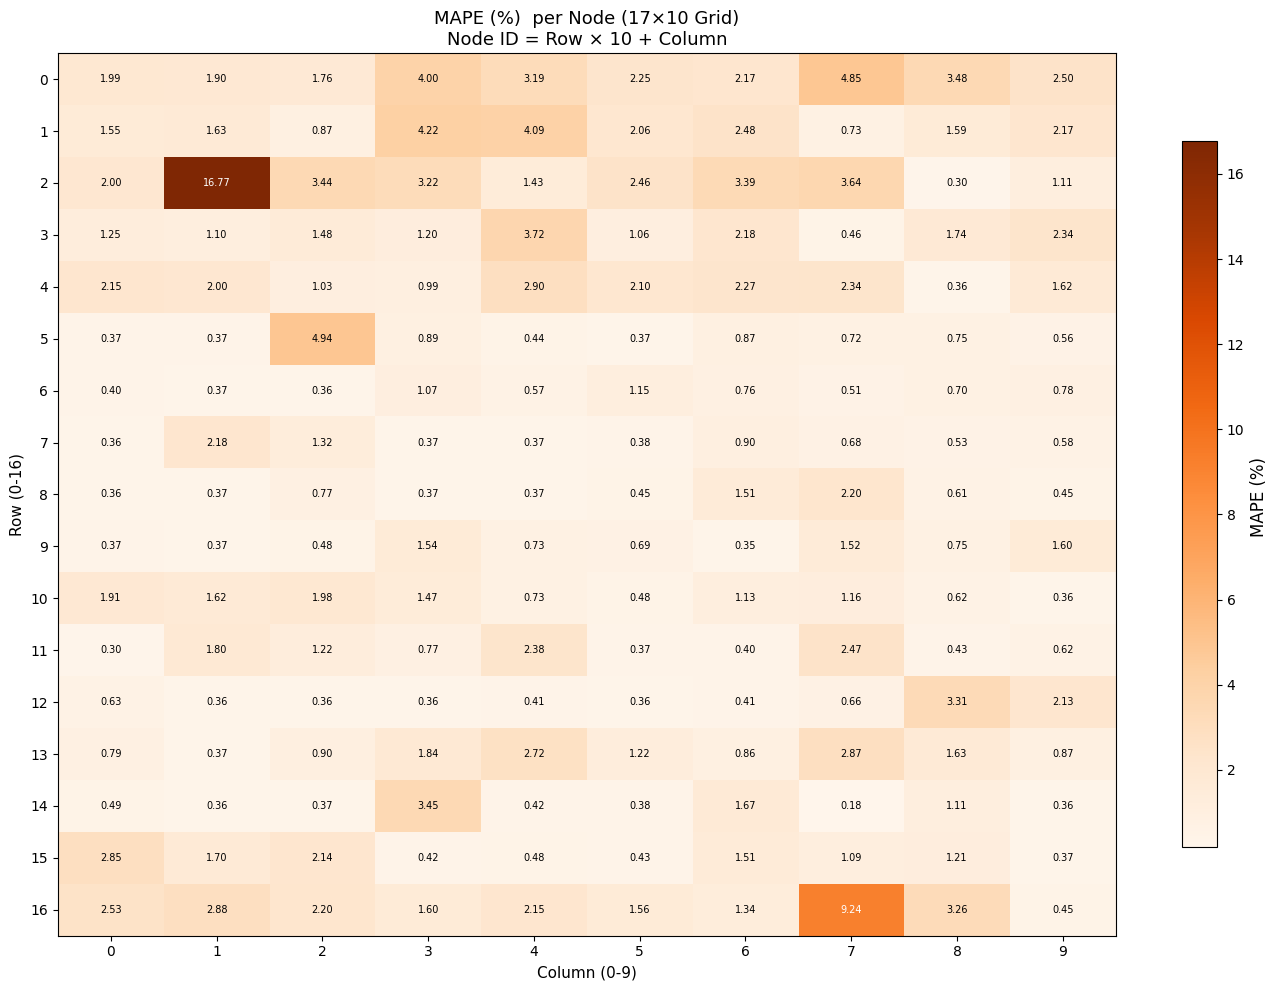

In [52]:
import seaborn as sns

def plot_node_metric_heatmap(metric_values, metric_name, cmap='YlOrRd', figsize=(14, 10)):
    """
    Plot a heatmap of per-node metrics in a 17x10 grid layout.
    """
    # Reshape 170 nodes into 17x10 grid
    grid_rows, grid_cols = 17, 10
    
    # Pad to 170 if needed (already 170 nodes)
    metric_grid = metric_values.reshape(grid_rows, grid_cols)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(metric_grid, cmap=cmap, aspect='auto')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(metric_name, fontsize=12)
    
    # Add text annotations
    for i in range(grid_rows):
        for j in range(grid_cols):
            node_idx = i * grid_cols + j
            value = metric_grid[i, j]
            # Choose text color based on background
            text_color = 'white' if value > (metric_grid.max() + metric_grid.min()) / 2 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', 
                   fontsize=7, color=text_color)
    
    # Labels
    ax.set_xlabel('Column (0-9)', fontsize=11)
    ax.set_ylabel('Row (0-16)', fontsize=11)
    ax.set_title(f'{metric_name} per Node (17×10 Grid)\nNode ID = Row × 10 + Column', fontsize=13)
    
    # Set ticks
    ax.set_xticks(range(grid_cols))
    ax.set_yticks(range(grid_rows))
    
    plt.tight_layout()
    return fig

# Plot MAE Heatmap
fig_mae = plot_node_metric_heatmap(node_mae, 'MAE (Mean Absolute Error)', cmap='Blues')
plt.show()

# Plot RMSE Heatmap  
fig_rmse = plot_node_metric_heatmap(node_rmse, 'RMSE (Root Mean Squared Error)', cmap='Greens')
plt.show()

# Plot MAPE Heatmap
fig_mape = plot_node_metric_heatmap(node_mape, 'MAPE (%) ', cmap='Oranges')
plt.show()

### Multi-Node Prediction Comparison

Predictions vs Ground Truth for multiple nodes.

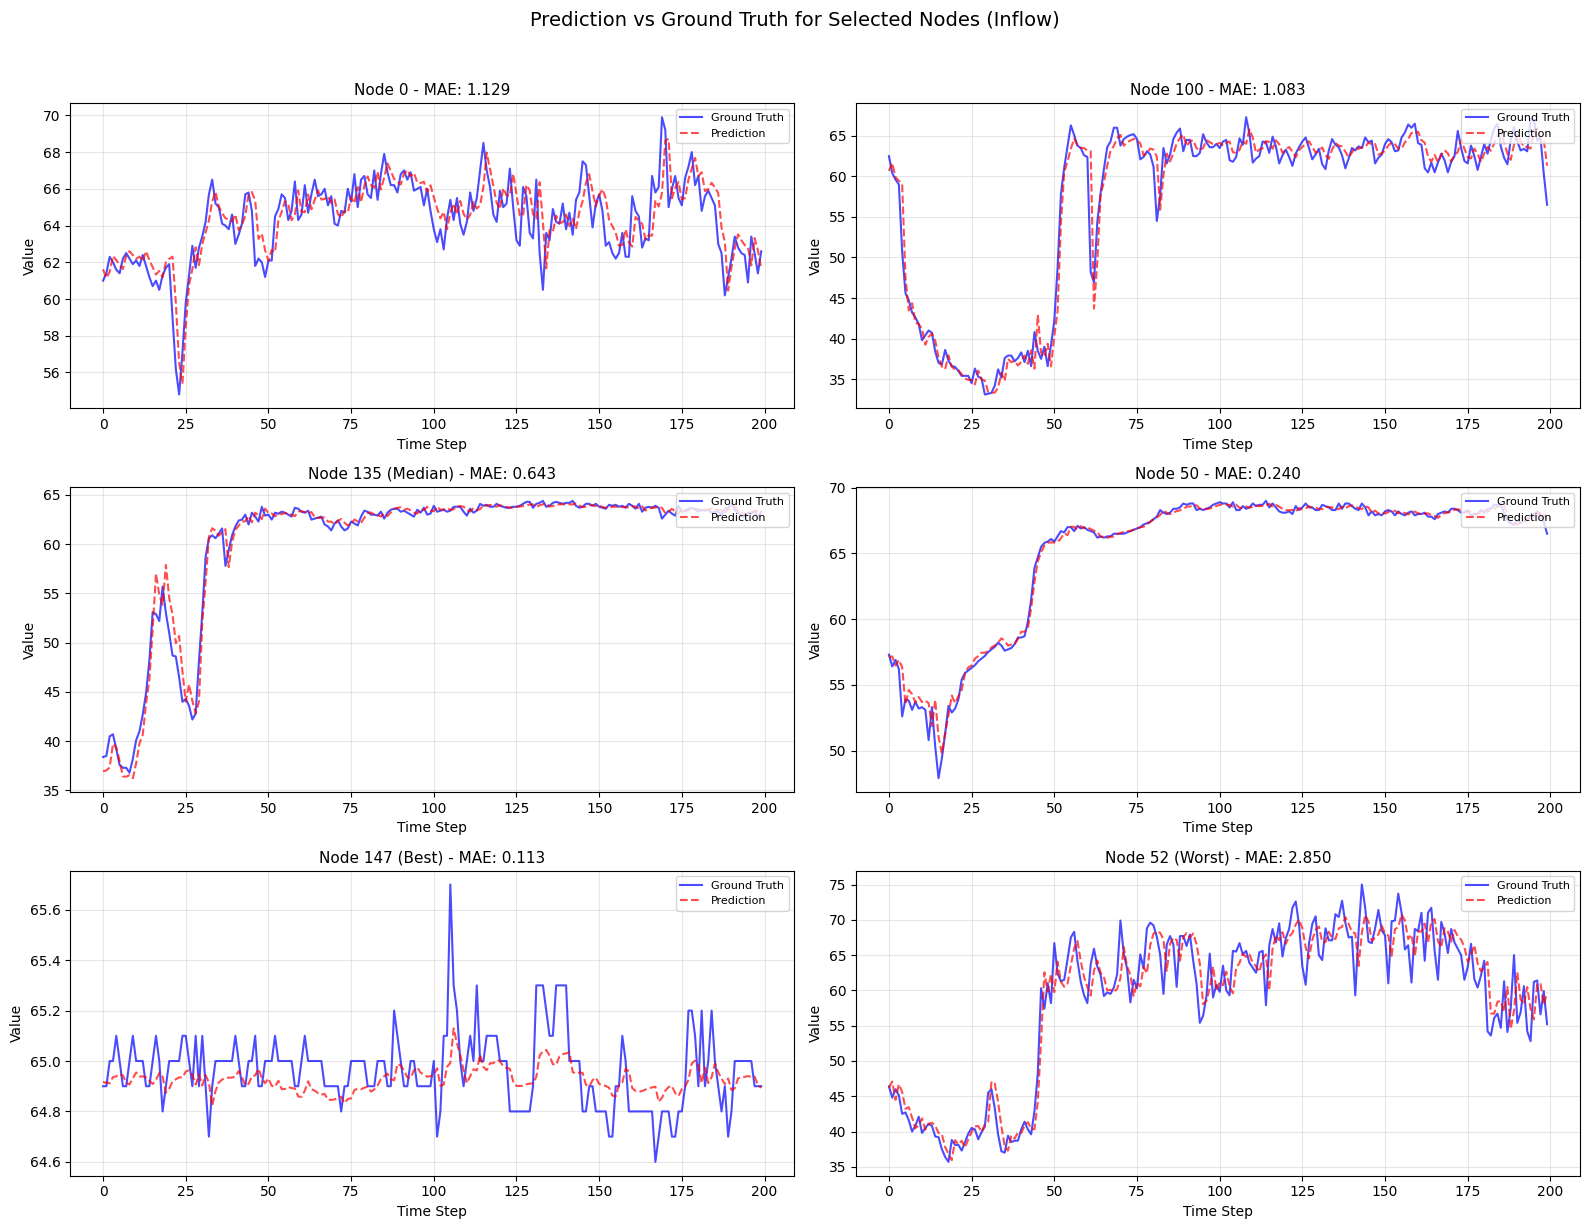


Best performing node: 147 (MAE: 0.1135)
Worst performing node: 52 (MAE: 2.8505)
Median performing node: 135 (MAE: 0.6432)


In [53]:
# Multi-node prediction plots - select diverse nodes (best, worst, median)
best_node = np.argmin(node_mae)
worst_node = np.argmax(node_mae)
median_node = np.argsort(node_mae)[len(node_mae)//2]

# Sample some additional nodes
sample_nodes = [0, 50, 100, 150, best_node, worst_node, median_node]
sample_nodes = list(set(sample_nodes))[:6]  # Unique nodes, max 6

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

time_steps = 200
feature_idx = 0  # Inflow

for idx, node in enumerate(sample_nodes):
    ax = axes[idx]
    gt = y_true[:time_steps, 0, node, feature_idx].cpu().numpy()
    pred = y_pred[:time_steps, 0, node, feature_idx].cpu().numpy()
    
    ax.plot(gt, label='Ground Truth', color='blue', alpha=0.7, linewidth=1.5)
    ax.plot(pred, label='Prediction', color='red', alpha=0.7, linestyle='--', linewidth=1.5)
    
    # Add node info
    node_info = ""
    if node == best_node:
        node_info = " (Best)"
    elif node == worst_node:
        node_info = " (Worst)"
    elif node == median_node:
        node_info = " (Median)"
    
    ax.set_title(f'Node {node}{node_info} - MAE: {node_mae[node]:.3f}', fontsize=11)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction vs Ground Truth for Selected Nodes (Inflow)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBest performing node: {best_node} (MAE: {node_mae[best_node]:.4f})")
print(f"Worst performing node: {worst_node} (MAE: {node_mae[worst_node]:.4f})")
print(f"Median performing node: {median_node} (MAE: {node_mae[median_node]:.4f})")

### Combined Metrics Summary Heatmap

Side-by-side comparison of all metrics normalized to [0,1] scale.

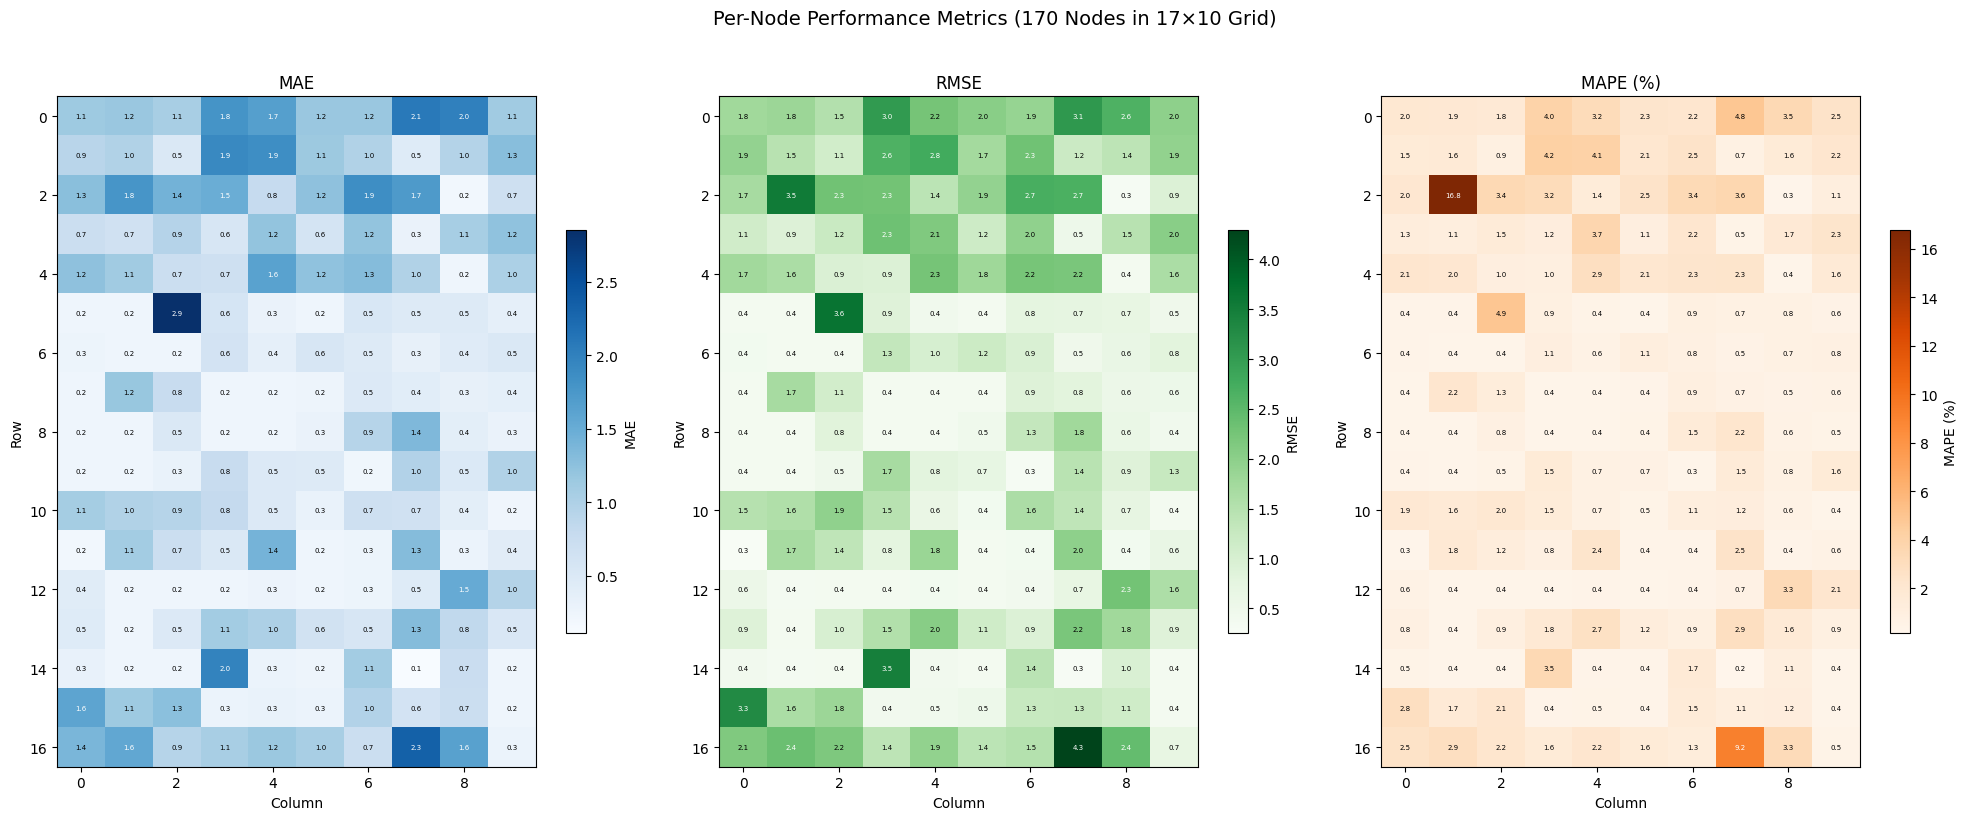


TOP 5 BEST PERFORMING NODES (by MAE)
  1. Node 147 - MAE: 0.1135, RMSE: 0.2784, MAPE: 0.18%
  2. Node 110 - MAE: 0.1952, RMSE: 0.2557, MAPE: 0.30%
  3. Node  28 - MAE: 0.1983, RMSE: 0.3112, MAPE: 0.30%
  4. Node  96 - MAE: 0.2196, RMSE: 0.2990, MAPE: 0.35%
  5. Node 109 - MAE: 0.2310, RMSE: 0.3676, MAPE: 0.36%

TOP 5 WORST PERFORMING NODES (by MAE)
  1. Node  52 - MAE: 2.8505, RMSE: 3.6469, MAPE: 4.94%
  2. Node 167 - MAE: 2.3328, RMSE: 4.2909, MAPE: 9.24%
  3. Node   7 - MAE: 2.0763, RMSE: 3.0736, MAPE: 4.85%
  4. Node   8 - MAE: 2.0032, RMSE: 2.6456, MAPE: 3.48%
  5. Node 143 - MAE: 1.9681, RMSE: 3.4589, MAPE: 3.45%


In [54]:
# Create a combined visualization with all three metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

grid_rows, grid_cols = 17, 10
metrics = [
    (node_mae, 'MAE', 'Blues'),
    (node_rmse, 'RMSE', 'Greens'),
    (node_mape, 'MAPE (%)', 'Oranges')
]

for ax, (metric_vals, metric_name, cmap) in zip(axes, metrics):
    metric_grid = metric_vals.reshape(grid_rows, grid_cols)
    
    im = ax.imshow(metric_grid, cmap=cmap, aspect='auto')
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label(metric_name, fontsize=10)
    
    # Add text annotations (smaller font for combined view)
    for i in range(grid_rows):
        for j in range(grid_cols):
            value = metric_grid[i, j]
            text_color = 'white' if value > (metric_grid.max() + metric_grid.min()) / 2 else 'black'
            ax.text(j, i, f'{value:.1f}', ha='center', va='center', 
                   fontsize=5, color=text_color)
    
    ax.set_xlabel('Column', fontsize=10)
    ax.set_ylabel('Row', fontsize=10)
    ax.set_title(f'{metric_name}', fontsize=12)
    ax.set_xticks(range(0, grid_cols, 2))
    ax.set_yticks(range(0, grid_rows, 2))

plt.suptitle('Per-Node Performance Metrics (170 Nodes in 17×10 Grid)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Node ranking summary
print("\n" + "="*60)
print("TOP 5 BEST PERFORMING NODES (by MAE)")
print("="*60)
best_indices = np.argsort(node_mae)[:5]
for rank, idx in enumerate(best_indices, 1):
    print(f"  {rank}. Node {idx:3d} - MAE: {node_mae[idx]:.4f}, RMSE: {node_rmse[idx]:.4f}, MAPE: {node_mape[idx]:.2f}%")

print("\n" + "="*60)
print("TOP 5 WORST PERFORMING NODES (by MAE)")
print("="*60)
worst_indices = np.argsort(node_mae)[-5:][::-1]
for rank, idx in enumerate(worst_indices, 1):
    print(f"  {rank}. Node {idx:3d} - MAE: {node_mae[idx]:.4f}, RMSE: {node_rmse[idx]:.4f}, MAPE: {node_mape[idx]:.2f}%")

### Why Low MAE ≠ Good Predictions: The Variance Problem

Node 147 has low MAE because the **ground truth values have very low variance**. A model predicting near-constant values will have low absolute error, but it's NOT capturing the actual patterns. Let's examine this with additional metrics.

In [57]:
# Calculate additional metrics that account for variance
from scipy.stats import pearsonr

# Per-node: R², Correlation, Variance of ground truth, Normalized MAE (MAE/std)
node_r2 = np.zeros(num_nodes)
node_correlation = np.zeros(num_nodes)
node_variance = np.zeros(num_nodes)
node_normalized_mae = np.zeros(num_nodes)  # MAE / std(y_true)

for node in range(num_nodes):
    y_t = y_true_np[:, :, node, :].flatten()
    y_p = y_pred_np[:, :, node, :].flatten()
    
    # R² score
    ss_res = np.sum((y_t - y_p) ** 2)
    ss_tot = np.sum((y_t - np.mean(y_t)) ** 2)
    node_r2[node] = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Pearson correlation
    node_correlation[node], _ = pearsonr(y_t, y_p)
    
    # Variance of ground truth
    node_variance[node] = np.var(y_t)
    
    # Normalized MAE (MAE / std)
    std = np.std(y_t)
    node_normalized_mae[node] = node_mae[node] / std if std > 0 else 0

print("="*70)
print("COMPARING NODE 147 (Lowest MAE) vs NODE 52 (Highest MAE)")
print("="*70)
print(f"\n{'Metric':<25} {'Node 147':>15} {'Node 52':>15}")
print("-"*55)
print(f"{'MAE':<25} {node_mae[147]:>15.4f} {node_mae[52]:>15.4f}")
print(f"{'RMSE':<25} {node_rmse[147]:>15.4f} {node_rmse[52]:>15.4f}")
print(f"{'Ground Truth Variance':<25} {node_variance[147]:>15.4f} {node_variance[52]:>15.4f}")
print(f"{'Ground Truth Std Dev':<25} {np.sqrt(node_variance[147]):>15.4f} {np.sqrt(node_variance[52]):>15.4f}")
print(f"{'R² Score':<25} {node_r2[147]:>15.4f} {node_r2[52]:>15.4f}")
print(f"{'Correlation':<25} {node_correlation[147]:>15.4f} {node_correlation[52]:>15.4f}")
print(f"{'Normalized MAE (MAE/Std)':<25} {node_normalized_mae[147]:>15.4f} {node_normalized_mae[52]:>15.4f}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print(f"""
• Node 147 has variance of only {node_variance[147]:.4f} (Std={np.sqrt(node_variance[147]):.4f})
  → The values barely change! Easy to get low MAE with flat predictions.
  → R² = {node_r2[147]:.4f} shows the model explains {node_r2[147]*100:.1f}% of variance

• Node 52 has variance of {node_variance[52]:.4f} (Std={np.sqrt(node_variance[52]):.4f})  
  → Much more dynamic data with bigger fluctuations
  → R² = {node_r2[52]:.4f} shows the model explains {node_r2[52]*100:.1f}% of variance
  
• Normalized MAE (MAE/Std) is a fairer comparison:
  → Node 147: {node_normalized_mae[147]:.4f} (relative to its variance)
  → Node 52:  {node_normalized_mae[52]:.4f} (relative to its variance)
""")

COMPARING NODE 147 (Lowest MAE) vs NODE 52 (Highest MAE)

Metric                           Node 147         Node 52
-------------------------------------------------------
MAE                                0.1135          2.8505
RMSE                               0.2784          3.6469
Ground Truth Variance              0.1041        108.1525
Ground Truth Std Dev               0.3226         10.3996
R² Score                           0.2549          0.8770
Correlation                        0.5260          0.9368
Normalized MAE (MAE/Std)           0.3518          0.2741

INTERPRETATION:

• Node 147 has variance of only 0.1041 (Std=0.3226)
  → The values barely change! Easy to get low MAE with flat predictions.
  → R² = 0.2549 shows the model explains 25.5% of variance

• Node 52 has variance of 108.1525 (Std=10.3996)  
  → Much more dynamic data with bigger fluctuations
  → R² = 0.8770 shows the model explains 87.7% of variance
  
• Normalized MAE (MAE/Std) is a fairer comparison:
  →

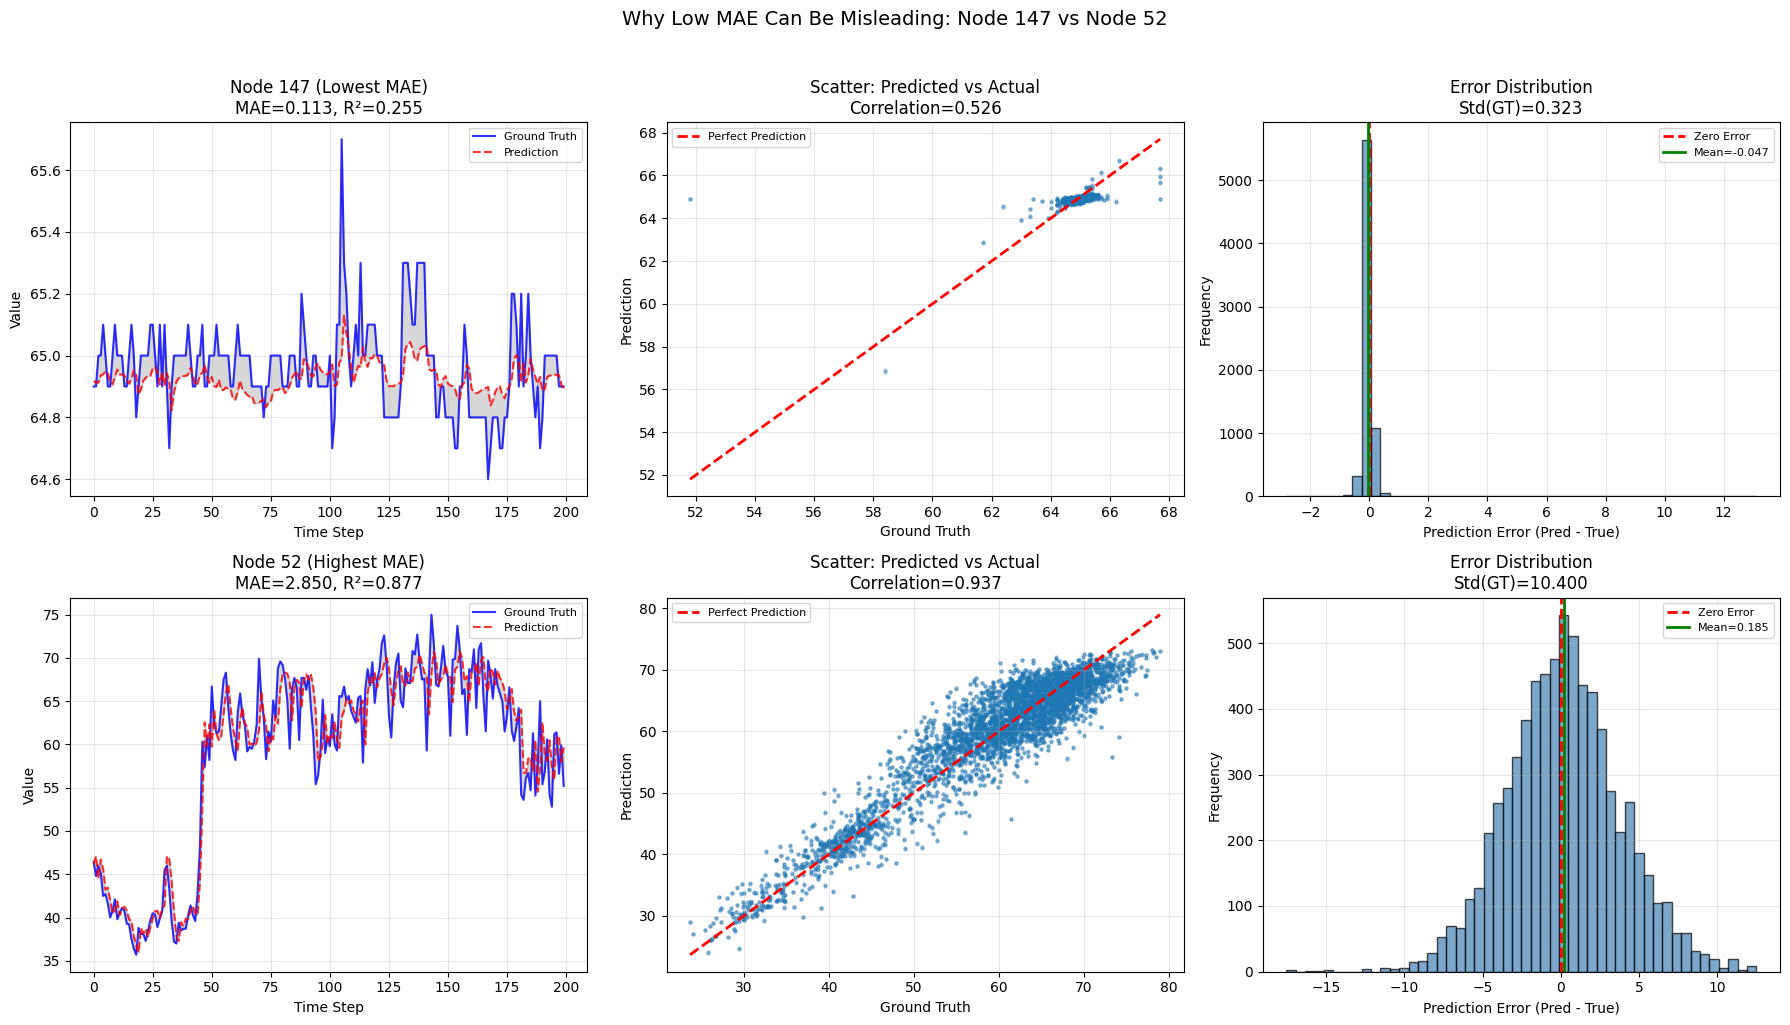

In [59]:
# Visual comparison: Node 147 vs Node 52
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

time_steps = 200
nodes_to_compare = [147, 52]
titles = ['Node 147 (Lowest MAE)', 'Node 52 (Highest MAE)']

for row, (node, title) in enumerate(zip(nodes_to_compare, titles)):
    # Time series plot
    ax = axes[row, 0]
    gt = y_true[:time_steps, 0, node, 0].cpu().numpy()
    pred = y_pred[:time_steps, 0, node, 0].cpu().numpy()
    ax.plot(gt, label='Ground Truth', color='blue', alpha=0.8, linewidth=1.5)
    ax.plot(pred, label='Prediction', color='red', alpha=0.8, linestyle='--', linewidth=1.5)
    ax.fill_between(range(len(gt)), gt, pred, alpha=0.3, color='gray')
    ax.set_title(f'{title}\nMAE={node_mae[node]:.3f}, R²={node_r2[node]:.3f}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Scatter plot: Predicted vs Actual
    ax = axes[row, 1]
    y_t_full = y_true_np[:, :, node, :].flatten()
    y_p_full = y_pred_np[:, :, node, :].flatten()
    ax.scatter(y_t_full, y_p_full, alpha=0.3, s=5)
    # Perfect prediction line
    min_val, max_val = min(y_t_full.min(), y_p_full.min()), max(y_t_full.max(), y_p_full.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediction')
    ax.set_title(f'Scatter: Predicted vs Actual\nCorrelation={node_correlation[node]:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Error distribution
    ax = axes[row, 2]
    errors = y_p_full - y_t_full
    ax.hist(errors, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.axvline(x=np.mean(errors), color='green', linestyle='-', linewidth=2, label=f'Mean={np.mean(errors):.3f}')
    ax.set_xlabel('Prediction Error (Pred - True)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Error Distribution\nStd(GT)={np.sqrt(node_variance[node]):.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Why Low MAE Can Be Misleading: Node 147 vs Node 52', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

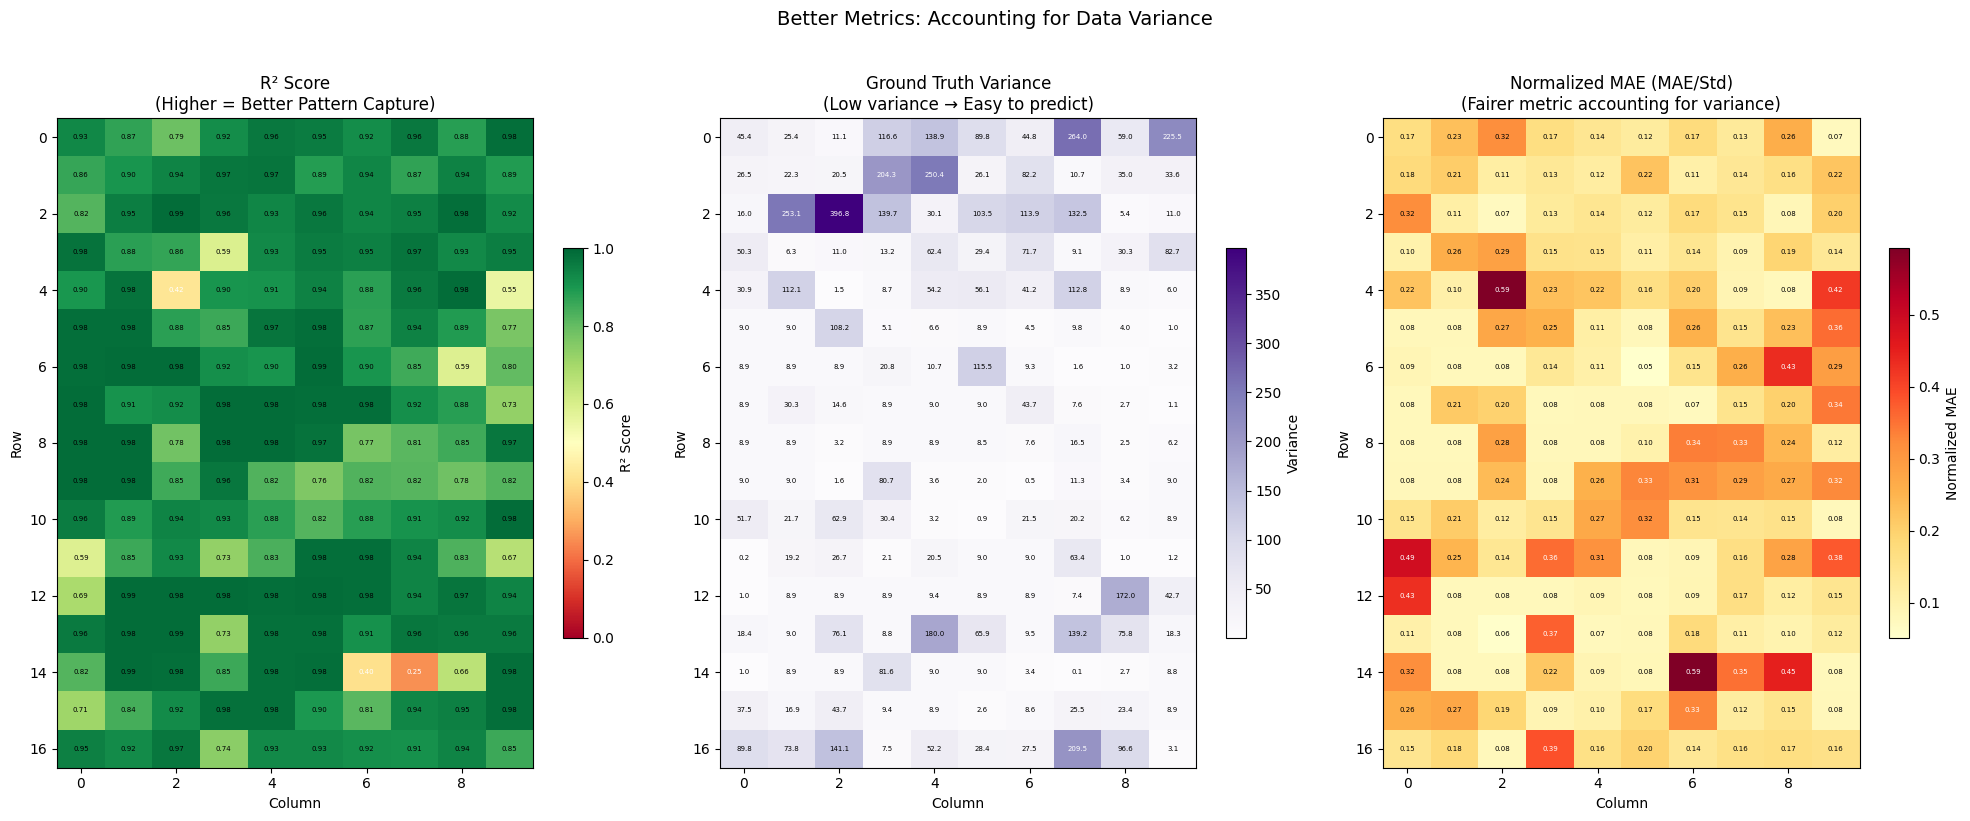


TOP 5 TRULY BEST NODES (by R² Score - Pattern Capture)
  1. Node  65 - R²: 0.9881, MAE: 0.5538, Variance: 115.51
  2. Node 132 - R²: 0.9872, MAE: 0.4808, Variance: 76.14
  3. Node  22 - R²: 0.9866, MAE: 1.4231, Variance: 396.79
  4. Node 141 - R²: 0.9851, MAE: 0.2329, Variance: 8.94
  5. Node 121 - R²: 0.9850, MAE: 0.2320, Variance: 8.94

TOP 5 TRULY WORST NODES (by R² Score)
  1. Node 147 - R²: 0.2549, MAE: 0.1135, Variance: 0.10
  2. Node 146 - R²: 0.4033, MAE: 1.0935, Variance: 3.41
  3. Node  42 - R²: 0.4196, MAE: 0.7299, Variance: 1.53
  4. Node  49 - R²: 0.5511, MAE: 1.0187, Variance: 5.97
  5. Node  68 - R²: 0.5893, MAE: 0.4369, Variance: 1.02

⚠️  Node 147 R² rank: 170 out of 170


In [60]:
# Heatmaps with better metrics: R² and Normalized MAE
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

grid_rows, grid_cols = 17, 10

# R² Heatmap (higher is better - use reversed colormap)
ax = axes[0]
r2_grid = node_r2.reshape(grid_rows, grid_cols)
im = ax.imshow(r2_grid, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('R² Score', fontsize=10)
for i in range(grid_rows):
    for j in range(grid_cols):
        value = r2_grid[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=5, color=text_color)
ax.set_title('R² Score\n(Higher = Better Pattern Capture)', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Variance Heatmap
ax = axes[1]
var_grid = node_variance.reshape(grid_rows, grid_cols)
im = ax.imshow(var_grid, cmap='Purples', aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Variance', fontsize=10)
for i in range(grid_rows):
    for j in range(grid_cols):
        value = var_grid[i, j]
        text_color = 'white' if value > (var_grid.max() + var_grid.min()) / 2 else 'black'
        ax.text(j, i, f'{value:.1f}', ha='center', va='center', fontsize=5, color=text_color)
ax.set_title('Ground Truth Variance\n(Low variance → Easy to predict)', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Normalized MAE Heatmap (MAE/Std - fairer comparison)
ax = axes[2]
norm_mae_grid = node_normalized_mae.reshape(grid_rows, grid_cols)
im = ax.imshow(norm_mae_grid, cmap='YlOrRd', aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Normalized MAE', fontsize=10)
for i in range(grid_rows):
    for j in range(grid_cols):
        value = norm_mae_grid[i, j]
        text_color = 'white' if value > (norm_mae_grid.max() + norm_mae_grid.min()) / 2 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=5, color=text_color)
ax.set_title('Normalized MAE (MAE/Std)\n(Fairer metric accounting for variance)', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')

plt.suptitle('Better Metrics: Accounting for Data Variance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Re-rank nodes by R² score (better metric for pattern capture)
print("\n" + "="*70)
print("TOP 5 TRULY BEST NODES (by R² Score - Pattern Capture)")
print("="*70)
best_r2_indices = np.argsort(node_r2)[::-1][:5]
for rank, idx in enumerate(best_r2_indices, 1):
    print(f"  {rank}. Node {idx:3d} - R²: {node_r2[idx]:.4f}, MAE: {node_mae[idx]:.4f}, Variance: {node_variance[idx]:.2f}")

print("\n" + "="*70)
print("TOP 5 TRULY WORST NODES (by R² Score)")
print("="*70)
worst_r2_indices = np.argsort(node_r2)[:5]
for rank, idx in enumerate(worst_r2_indices, 1):
    print(f"  {rank}. Node {idx:3d} - R²: {node_r2[idx]:.4f}, MAE: {node_mae[idx]:.4f}, Variance: {node_variance[idx]:.2f}")

print(f"\n⚠️  Node 147 R² rank: {np.where(np.argsort(node_r2)[::-1] == 147)[0][0] + 1} out of {num_nodes}")

### Loss Convergence

Visualize the training and validation loss over epochs.

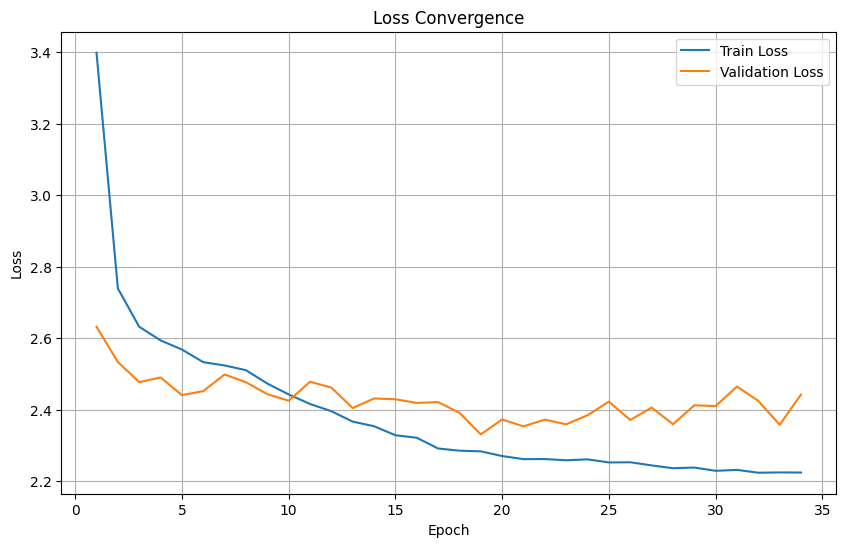

Final Train Loss: 2.223611623227239
Final Validation Loss: 2.441843217557615


In [48]:
stats_path = os.path.join(args.log_dir, 'stats.pkl')

if os.path.exists(stats_path):
    stats = pd.read_pickle(stats_path)
    
    plt.figure(figsize=(10, 6))
    plt.plot(stats['epoch'], stats['train_loss'], label='Train Loss')
    plt.plot(stats['epoch'], stats['val_loss'], label='Validation Loss')
    
    plt.title('Loss Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print("Final Train Loss:", stats['train_loss'].iloc[-1])
    print("Final Validation Loss:", stats['val_loss'].iloc[-1])
else:
    print("Stats file not found.")